In [8]:
# Install dependencies (only run if needed)
%pip install pandas matplotlib seaborn plotly scikit-learn --quiet

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load raw data
team_summaries = pd.read_csv("data/raw/Team Summaries.csv")
opp_stats = pd.read_csv("data/raw/Opponent Stats Per Game.csv")
team_stats = pd.read_csv("data/raw/Team Stats Per Game.csv")

# Filter NBA seasons
team_summaries = team_summaries[(team_summaries['lg'] == 'NBA') & (team_summaries['season'] >= 2003) & (team_summaries['season'] <= 2025)]
opp_stats = opp_stats[(opp_stats['season'] >= 2003) & (opp_stats['season'] <= 2025)]


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
# Merge defensive features before normalization
# Derived feature: opponent 3PA rate
opp_stats['opp_3p_rate'] = opp_stats['opp_x3pa_per_game'] / opp_stats['opp_fga_per_game']

# Load team-level defensive stats
team_stats = pd.read_csv("data/raw/Team Stats Per Game.csv")
team_stats = team_stats[(team_stats['season'] >= 2003) & (team_stats['season'] <= 2025)]

# Merge all features together
merged = team_summaries.merge(
    opp_stats[['season', 'team', 'opp_fg_percent', 'opp_tov_per_game', 'opp_drb_per_game', 'opp_fta_per_game',
               'opp_3p_rate', 'opp_pts_per_game', 'opp_ast_per_game']].copy(),
    on=['season', 'team'], how='left'
).merge(
    team_stats[['season', 'team', 'blk_per_game', 'stl_per_game', 'drb_per_game']].copy(),
    on=['season', 'team'], how='left'
)

# Rename for consistency
merged = merged.rename(columns={
    'opp_fg_percent': 'opp_e_fg_percent',
    'opp_tov_per_game': 'opp_tov_percent',
    'opp_drb_per_game': 'opp_drb_percent',
    'opp_fta_per_game': 'opp_ft_fga'
})

# Add Win% if missing
if 'w' in merged.columns and 'l' in merged.columns and 'Win%' not in merged.columns:
    merged['Win%'] = merged['w'] / (merged['w'] + merged['l'])

# Define feature set (not normalizing yet)
features = [
    'opp_e_fg_percent', 'opp_tov_percent', 'opp_drb_percent', 'opp_ft_fga',
    'opp_3p_rate', 'opp_pts_per_game', 'opp_ast_per_game',
    'blk_per_game', 'stl_per_game', 'drb_per_game'
]

# Only normalize d_rtg (for future defensive profiling)
if 'd_rtg' in team_summaries.columns:
    merged['d_rtg_z'] = merged.groupby('season')['d_rtg'].transform(lambda x: (x - x.mean()) / x.std())
    norm_cols = ['d_rtg_z']
else:
    print("Warning: 'd_rtg' column not found in team_summaries")
    norm_cols = []

merged.fillna(0, inplace=True)


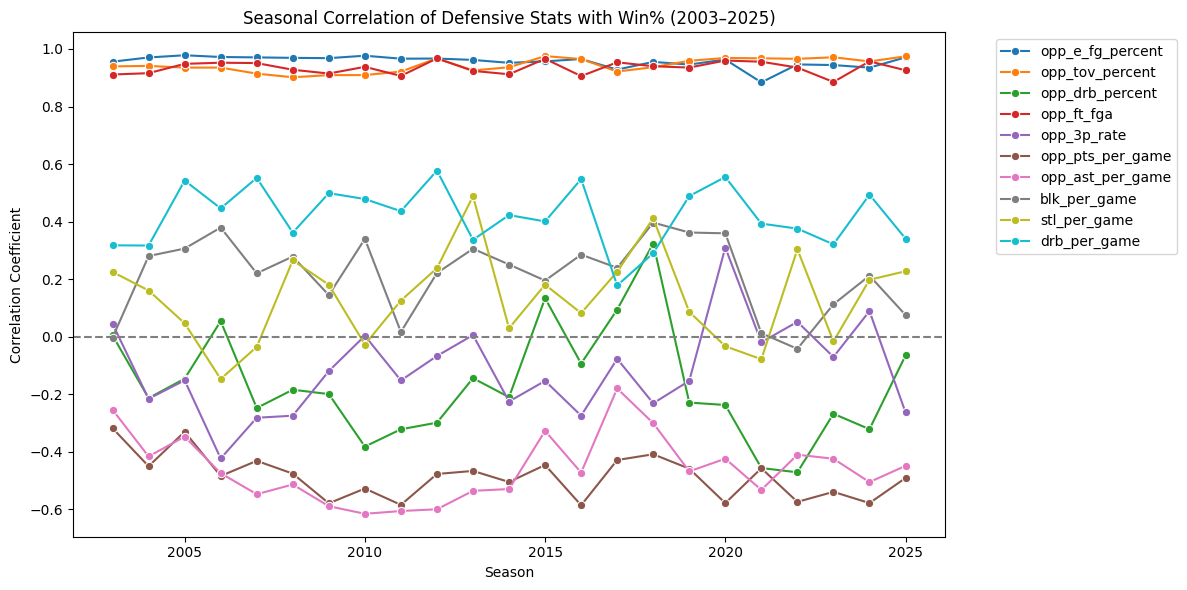

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute stat-to-win% correlation over time
season_corrs_win = []

for year in range(2003, 2026):
    sub_df = merged[merged['season'] == year]
    if sub_df.shape[0] > 5 and 'Win%' in sub_df.columns:
        row = {'season': year}
        for stat in ['opp_e_fg_percent', 'opp_tov_percent', 'opp_drb_percent', 'opp_ft_fga', 
                     'opp_3p_rate', 'opp_pts_per_game', 'opp_ast_per_game',
                     'blk_per_game', 'stl_per_game', 'drb_per_game']:
            if stat in sub_df.columns:
                row[stat] = sub_df[[stat, 'Win%']].corr().iloc[0, 1]
        season_corrs_win.append(row)

corrs_win_df = pd.DataFrame(season_corrs_win)
melted_win = corrs_win_df.melt(id_vars='season', var_name='Metric', value_name='Correlation with Win%')

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_win, x='season', y='Correlation with Win%', hue='Metric', marker='o')
plt.title("Seasonal Correlation of Defensive Stats with Win% (2003–2025)")
plt.xlabel("Season")
plt.ylabel("Correlation Coefficient")
plt.axhline(0, linestyle='--', color='gray')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


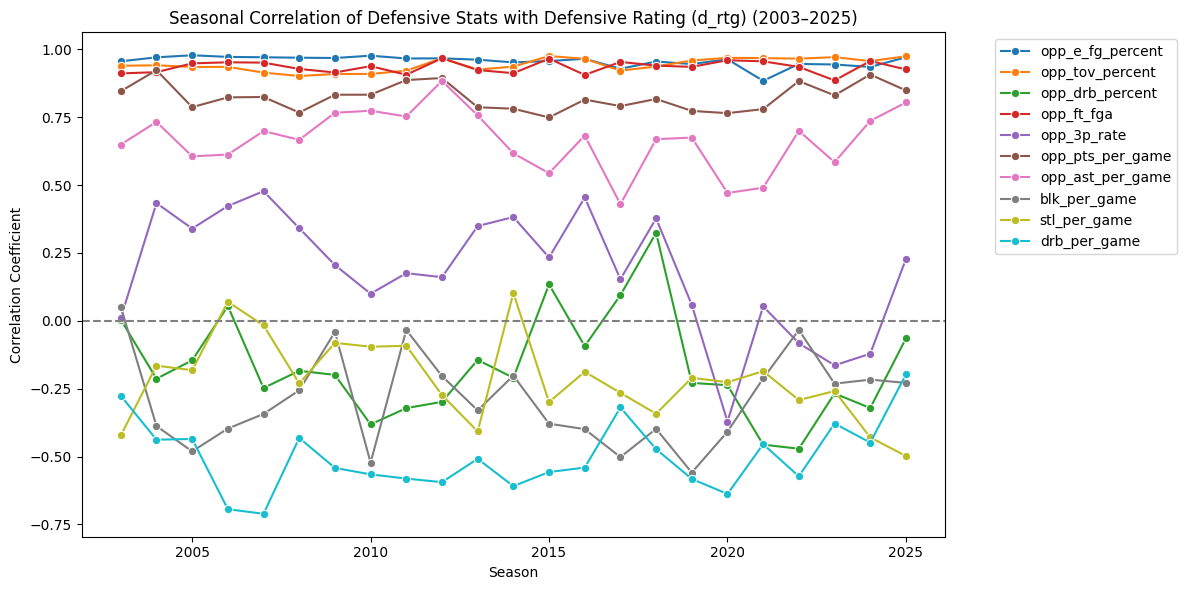

In [11]:

# Compute stat-to-d_rtg correlation over time
season_corrs_drtg = []

for year in range(2003, 2026):
    sub_df = merged[merged['season'] == year]
    if sub_df.shape[0] > 5 and 'd_rtg' in sub_df.columns:
        row = {'season': year}
        for stat in ['opp_e_fg_percent', 'opp_tov_percent', 'opp_drb_percent', 'opp_ft_fga', 
                     'opp_3p_rate', 'opp_pts_per_game', 'opp_ast_per_game',
                     'blk_per_game', 'stl_per_game', 'drb_per_game']:
            if stat in sub_df.columns:
                row[stat] = sub_df[[stat, 'd_rtg']].corr().iloc[0, 1]
        season_corrs_drtg.append(row)

corrs_drtg_df = pd.DataFrame(season_corrs_drtg)
melted_drtg = corrs_drtg_df.melt(id_vars='season', var_name='Metric', value_name='Correlation with d_rtg')

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_drtg, x='season', y='Correlation with d_rtg', hue='Metric', marker='o')
plt.title("Seasonal Correlation of Defensive Stats with Defensive Rating (d_rtg) (2003–2025)")
plt.xlabel("Season")
plt.ylabel("Correlation Coefficient")
plt.axhline(0, linestyle='--', color='gray')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


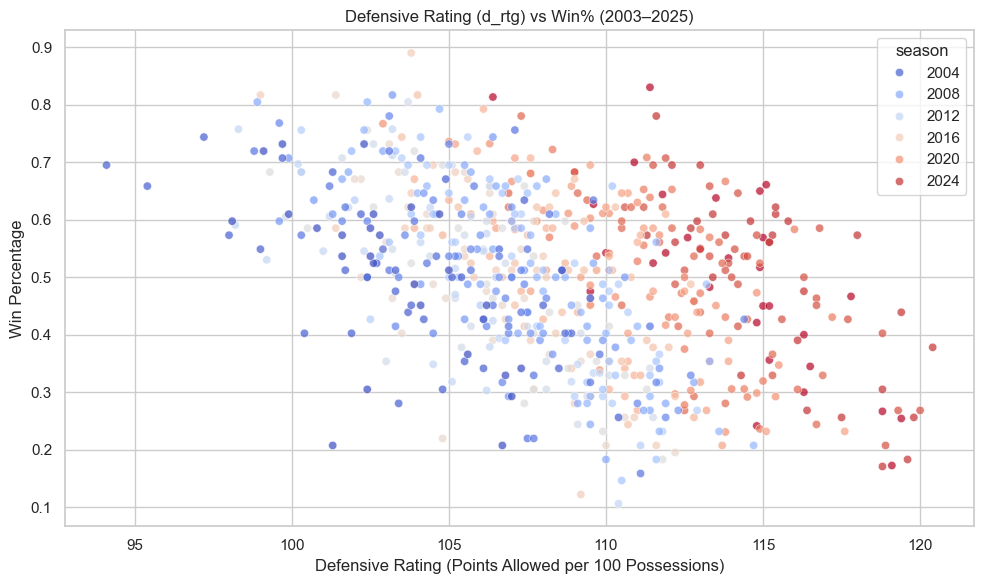

In [ ]:
# Scatterplot: Opponent points per 100 possessions vs Win%
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='d_rtg', y='Win%', hue='season', palette='coolwarm', alpha=0.7)
plt.title("Defensive Rating (d_rtg) vs Win% (2003–2025)")
plt.xlabel("Defensive Rating (Points Allowed per 100 Possessions)")
plt.ylabel("Win Percentage")
plt.tight_layout()
plt.show()


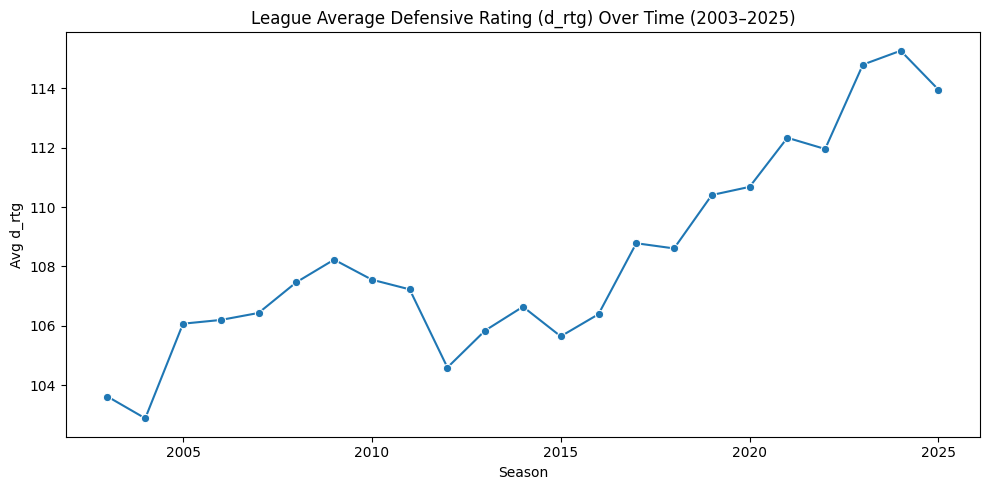

In [15]:
# Plot league average d_rtg over time
plt.figure(figsize=(10, 5))
sns.lineplot(data=merged.groupby('season')['d_rtg'].mean().reset_index(), x='season', y='d_rtg', marker='o')
plt.title("League Average Defensive Rating (d_rtg) Over Time (2003–2025)")
plt.xlabel("Season")
plt.ylabel("Avg d_rtg")
plt.tight_layout()
plt.show()

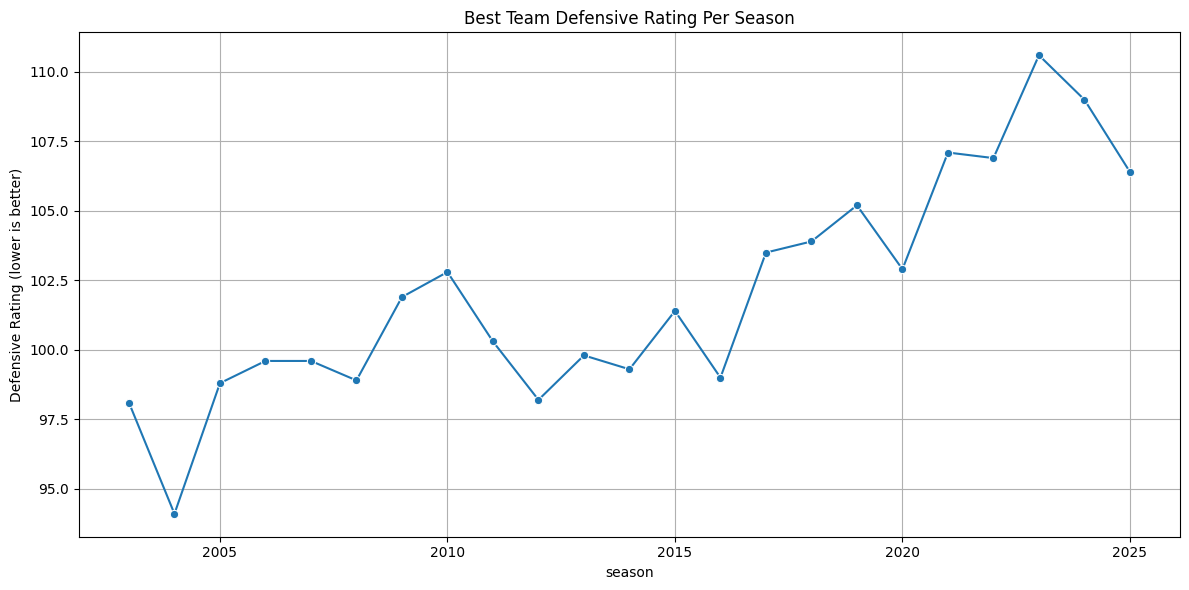

In [13]:
best_def_per_season = merged.loc[merged.groupby('season')['d_rtg'].idxmin()]
plt.figure(figsize=(12, 6))
sns.lineplot(data=best_def_per_season, x='season', y='d_rtg', marker='o')
plt.title("Best Team Defensive Rating Per Season")
plt.ylabel("Defensive Rating (lower is better)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Normalize d_rtg within each season
df['d_rtg_z'] = df.groupby('season')['d_rtg'].transform(lambda x: (x - x.mean()) / x.std())

# Get best defensive team per season
best_def_teams = df.sort_values(by='d_rtg_z').groupby('season').first().reset_index()

# Format clean summary list
best_def_summary = best_def_teams[['season', 'team', 'd_rtg', 'Win%']].sort_values(by='season')
best_def_summary.columns = ['Season', 'Best Defensive Team', 'Defensive Rating (d_rtg)', 'Win Percentage']

# Display the list
from IPython.display import display
display(best_def_summary)


,Season,Best Defensive Team,Defensive Rating (d_rtg),Win Percentage
0,2003,New Jersey Nets,98.1,0.597561
1,2004,San Antonio Spurs,94.1,0.695122
2,2005,San Antonio Spurs,98.8,0.719512
3,2006,San Antonio Spurs,99.6,0.768293
4,2007,Chicago Bulls,99.6,0.597561
5,2008,Boston Celtics,98.9,0.804878
6,2009,Orlando Magic,101.9,0.719512
7,2010,Charlotte Bobcats,102.8,0.536585
8,2011,Chicago Bulls,100.3,0.756098
9,2012,Boston Celtics,98.2,0.590909


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Step 1: Select top 10 defensive teams per season (lowest d_rtg_z)
top_10_teams = merged.sort_values(by='d_rtg_z').groupby('season').head(10).reset_index(drop=True)

# Step 2: Feature engineering — estimate possessions per game (via pace)
top_10_teams['poss_per_game'] = top_10_teams['pace']  # assuming pace is already in team_summaries

# Merge FG allowed per game from opponent stats
opp_pg = pd.read_csv("data/raw/Opponent Stats Per Game.csv")
top_10_teams = top_10_teams.merge(
    opp_pg[['season', 'team', 'opp_fg_per_game']],
    on=['season', 'team'], how='left'
)

# Derived metric: Adjusted pace pressure (how few FGs allowed given pace)
top_10_teams['pace_fg_ratio'] = top_10_teams['poss_per_game'] / top_10_teams['opp_fg_per_game']

# Step 3: Select features for clustering including season to account for temporal shifts
features = [
    'opp_e_fg_percent',    # top predictor of Win%
    'opp_tov_percent',     # second strongest
    'opp_ft_fga',          # discipline-based metric
    'pace_fg_ratio',       # pace-adjusted suppression
    'blk_per_game',        # rim protection
    'stl_per_game',        # on-ball disruption
    'season'               # include season to encode temporal context
]

# Step 4: Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(top_10_teams[features])

# Step 5: Apply KMeans clustering (7 clusters)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
top_10_teams['Cluster'] = kmeans.fit_predict(X)

# Step 6: Profile clusters with meaningful defensive outcomes
cluster_profiles = top_10_teams.groupby('Cluster')[features[:-1] + ['Win%', 'd_rtg']].mean().round(2)  # exclude 'season' from display
cluster_profiles['Team Count'] = top_10_teams['Cluster'].value_counts().sort_index()

# Display profiles for interpretation
from IPython.display import display
print("\n--- Defensive Cluster Profiles ---\n")
display(cluster_profiles)

# Optional: Save to CSV for further visualization
cluster_profiles.to_csv("data/processed/defensive_cluster_profiles.csv")
# Save clustered defensive teams to a CSV file
top_10_teams.to_csv("data/processed/clustered_defensive_teams.csv", index=False)


--- Defensive Cluster Profiles ---



,opp_e_fg_percent,opp_e_fg_percent,opp_tov_percent,opp_tov_percent,opp_ft_fga,opp_ft_fga,pace_fg_ratio,blk_per_game,stl_per_game,Win%,d_rtg,Team Count
Cluster,,,,,,,,,,,,
0,0.48,0.44,14.69,15.86,0.21,23.36,2.62,5.48,8.73,0.66,101.89,43
1,0.52,0.46,13.56,14.97,0.20,22.23,2.49,5.06,8.26,0.60,108.40,58
2,0.51,0.45,11.91,12.99,0.18,20.48,2.45,4.83,7.05,0.60,108.45,39
3,0.48,0.44,14.63,15.31,0.26,26.55,2.66,4.60,7.73,0.55,102.89,30
4,0.48,0.44,13.04,13.75,0.22,23.28,2.57,5.28,7.10,0.63,102.97,60


In [ ]:
from IPython.display import display

# Sort all teams by defensive rating (lower = better) within each cluster
all_by_drtg = (
    top_10_teams
    .sort_values(by=['Cluster', 'd_rtg'])
    .reset_index(drop=True)
)

# Sort all teams by Win% (higher = better) within each cluster
all_by_win = (
    top_10_teams
    .sort_values(by=['Cluster', 'Win%'], ascending=[True, False])
    .reset_index(drop=True)
)

# Define columns to include in display and export
display_cols = ['season', 'team', 'Cluster', 'd_rtg', 'Win%'] + features

# Display in notebook
print("\n📊 All Defensive Teams by d_rtg (sorted per Cluster):\n")
display(all_by_drtg[display_cols])

print("\n📊 All Defensive Teams by Win% (sorted per Cluster):\n")
display(all_by_win[display_cols])

# Save full data for external use
all_by_drtg[display_cols].to_csv("data/processed/best_by_drtg_per_cluster.csv", index=False)
all_by_win[display_cols].to_csv("data/processed/best_by_win_per_cluster.csv", index=False)



📊 All Defensive Teams by d_rtg (sorted per Cluster):



,season,team,Cluster,d_rtg,Win%,opp_e_fg_percent,opp_e_fg_percent,opp_tov_percent,opp_tov_percent,opp_ft_fga,opp_ft_fga,pace_fg_ratio,blk_per_game,stl_per_game,season
0,2004,San Antonio Spurs,0,94.1,0.695122,0.433,0.409,14.8,15.3,0.215,22.5,2.796238,6.5,8.1,2004
1,2004,Detroit Pistons,0,95.4,0.658537,0.441,0.413,15.5,16.0,0.202,21.1,2.738318,7.0,8.0,2004
2,2004,Indiana Pacers,0,97.2,0.743902,0.459,0.432,15.7,15.9,0.218,22.0,2.684049,5.0,8.9,2004
3,2004,New Jersey Nets,0,98.0,0.573171,0.460,0.427,15.7,16.1,0.221,22.3,2.725610,3.9,8.6,2004
4,2003,New Jersey Nets,0,98.1,0.597561,0.460,0.427,15.7,16.6,0.225,23.7,2.726190,4.6,8.7,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,2009,Charlotte Bobcats,4,106.1,0.426829,0.498,0.454,14.4,14.7,0.229,23.5,2.508523,4.8,7.1,2009
226,2008,Dallas Mavericks,4,106.1,0.621951,0.474,0.443,11.7,12.2,0.252,26.4,2.548023,4.9,6.0,2008
227,2017,Miami Heat,4,106.7,0.500000,0.496,0.450,12.6,13.7,0.220,23.7,2.511873,5.7,7.2,2017
228,2009,New Orleans Hornets,4,107.0,0.597561,0.496,0.450,13.2,13.3,0.230,22.9,2.522989,4.1,7.2,2009



📊 All Defensive Teams by Win% (sorted per Cluster):



,season,team,Cluster,d_rtg,Win%,opp_e_fg_percent,opp_e_fg_percent,opp_tov_percent,opp_tov_percent,opp_ft_fga,opp_ft_fga,pace_fg_ratio,blk_per_game,stl_per_game,season
0,2016,San Antonio Spurs,0,99.0,0.817073,0.477,0.436,14.1,14.8,0.182,19.6,2.627451,5.9,8.3,2016
1,2017,Golden State Warriors,0,104.0,0.817073,0.486,0.435,13.5,15.5,0.198,23.2,2.572165,6.8,9.6,2017
2,2015,Golden State Warriors,0,101.4,0.817073,0.470,0.428,14.3,16.2,0.217,24.5,2.656757,6.0,9.3,2015
3,2025,Oklahoma City Thunder,0,106.4,0.813559,0.508,0.432,15.6,17.9,0.222,24.8,2.687332,5.6,10.8,2025
4,2013,Miami Heat,0,103.7,0.804878,0.487,0.440,14.8,15.6,0.200,21.2,2.547753,5.4,8.7,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,2007,Los Angeles Clippers,4,105.6,0.487805,0.488,0.452,13.3,13.8,0.249,26.1,2.557746,5.8,7.3,2007
226,2015,Indiana Pacers,4,103.2,0.463415,0.478,0.435,12.0,12.7,0.217,23.8,2.588889,4.6,6.2,2015
227,2009,Charlotte Bobcats,4,106.1,0.426829,0.498,0.454,14.4,14.7,0.229,23.5,2.508523,4.8,7.1,2009
228,2006,Minnesota Timberwolves,4,104.5,0.402439,0.475,0.441,13.4,13.9,0.236,25.3,2.551724,5.7,6.8,2006


/var/folders/k5/1511xdl10db532886zr1dzb40000gn/T/ipykernel_44361/3385462351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_10_teams, x='Cluster', y='season', palette='tab10')


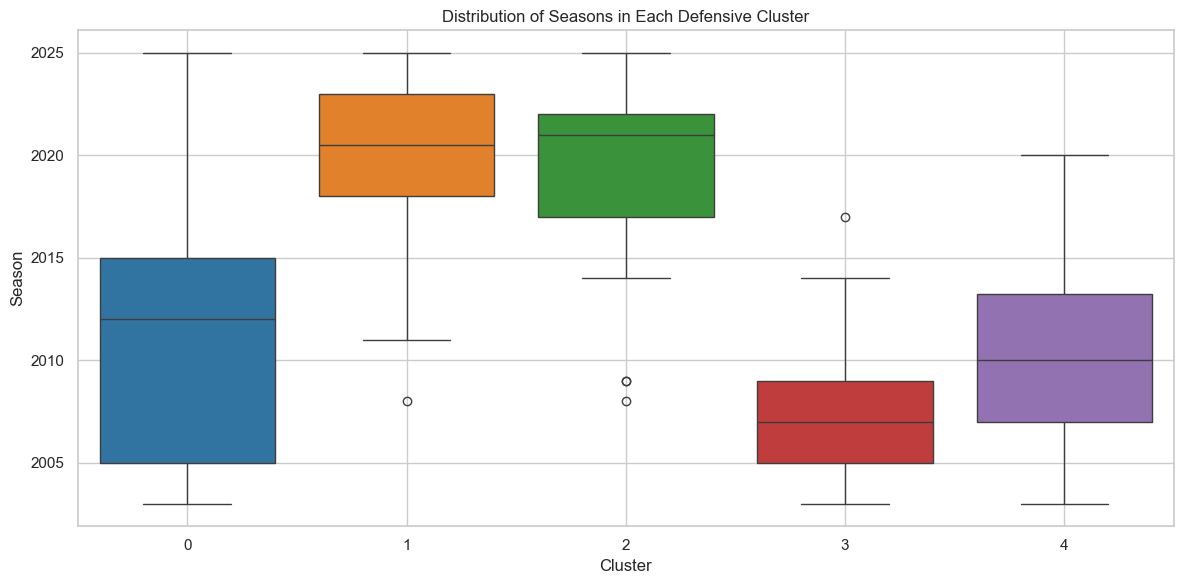

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=top_10_teams, x='Cluster', y='season', palette='tab10')

plt.title("Distribution of Seasons in Each Defensive Cluster")
plt.xlabel("Cluster")
plt.ylabel("Season")
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd

# Load clustered team data
clustered = pd.read_csv("data/processed/clustered_defensive_teams.csv")

# Define NBA champions manually (or load from another file if available)
champions = {
    2003: "San Antonio Spurs",
    2004: "Detroit Pistons",
    2005: "San Antonio Spurs",
    2006: "Miami Heat",
    2007: "San Antonio Spurs",
    2008: "Boston Celtics",
    2009: "Los Angeles Lakers",
    2010: "Los Angeles Lakers",
    2011: "Dallas Mavericks",
    2012: "Miami Heat",
    2013: "Miami Heat",
    2014: "San Antonio Spurs",
    2015: "Golden State Warriors",
    2016: "Cleveland Cavaliers",
    2017: "Golden State Warriors",
    2018: "Golden State Warriors",
    2019: "Toronto Raptors",
    2020: "Los Angeles Lakers",
    2021: "Milwaukee Bucks",
    2022: "Golden State Warriors",
    2023: "Denver Nuggets",
    2024: "Boston Celtics"
}

# Create a DataFrame from the champion dictionary
champ_df = pd.DataFrame(list(champions.items()), columns=['season', 'team'])

# Merge to get cluster info
champ_with_clusters = champ_df.merge(clustered[['season', 'team', 'Cluster']], on=['season', 'team'], how='left')

# Sort by season
champ_with_clusters_sorted = champ_with_clusters.sort_values(by='season')

# Display the results
print("🏆 NBA Champions and Their Defensive Clusters (2003–2024):")
display(champ_with_clusters_sorted)

# Optional: Save to CSV
champ_with_clusters_sorted.to_csv("data/processed/championships_by_cluster.csv", index=False)

🏆 NBA Champions and Their Defensive Clusters (2003–2024):


,season,team,Cluster
0,2003,San Antonio Spurs,0.0
1,2004,Detroit Pistons,0.0
2,2005,San Antonio Spurs,0.0
3,2006,Miami Heat,4.0
4,2007,San Antonio Spurs,4.0
5,2008,Boston Celtics,3.0
6,2009,Los Angeles Lakers,0.0
7,2010,Los Angeles Lakers,4.0
8,2011,Dallas Mavericks,4.0
9,2012,Miami Heat,0.0


# Exploratory Analysis of NBA Defensive Profiling (2003–2025)

This notebook performs an exploratory analysis of NBA defensive statistics from 2003 to 2025. The analysis includes data preprocessing, feature engineering, clustering, and visualization of defensive metrics.

## Key Steps in the Notebook

### 1. Data Loading and Preprocessing
- **Raw Data Sources**:
  - `Team Summaries.csv`
  - `Opponent Stats Per Game.csv`
  - `Team Stats Per Game.csv`
- **Filtering**:
  - Data is filtered to include only NBA seasons from 2003 to 2025.
- **Feature Engineering**:
  - Derived metrics such as opponent 3-point attempt rate (`opp_3p_rate`) and normalized defensive rating (`d_rtg_z`).

### 2. Merging and Cleaning Data
- Merged datasets to create a comprehensive DataFrame (`merged`) containing team-level and opponent-level statistics.
- Renamed columns for consistency and filled missing values with `0`.

### 3. Correlation Analysis
- **Win% Correlation**:
  - Seasonal correlation of defensive stats with Win% is computed and visualized.
- **Defensive Rating Correlation**:
  - Seasonal correlation of defensive stats with defensive rating (`d_rtg`) is computed and visualized.

### 4. Clustering Defensive Teams
- **Top 10 Defensive Teams**:
  - Selected the top 10 teams per season based on normalized defensive rating (`d_rtg_z`).
- **Feature Engineering**:
  - Added pace-adjusted metrics such as `pace_fg_ratio`.
- **Clustering**:
  - Applied KMeans clustering to group teams into 5 clusters based on defensive metrics.
- **Cluster Profiles**:
  - Generated profiles summarizing the characteristics of each cluster.

### 5. Visualizations
- **Seasonal Trends**:
  - Plots showing league-average defensive rating over time and the best defensive team per season.
- **Cluster Distributions**:
  - Boxplots showing the distribution of seasons within each defensive cluster.

### 6. NBA Champions and Defensive Clusters
- **Champion Analysis**:
  - Merged NBA champions (2003–2024) with cluster information to analyze their defensive profiles.
- **Exclusions**:
  - Noted that some championship teams (e.g., 2018 Warriors, 2023 Nuggets) were excluded from clustering due to lower regular-season defensive rankings.

### 7. Outputs
- **Saved Files**:
  - `data/processed/clustered_defensive_teams.csv`: Contains clustered defensive teams.
  - `data/processed/defensive_cluster_profiles.csv`: Profiles of defensive clusters.
  - `data/processed/championships_by_cluster.csv`: NBA champions with their defensive cluster assignments.

## Key Findings
- Defensive metrics such as opponent effective field goal percentage (`opp_e_fg_percent`) and turnover percentage (`opp_tov_percent`) are strong predictors of team success.
- Clustering revealed distinct defensive styles among top-performing teams.
- Only 2 championship teams succeeded despite not being among the top 10 regular-season defenses and they elevated in post season; might incorporate into future clustering.
### Next Steps
- Assigning all NBA teams to the created clusters.
- Assigning names to existing clusters.
- Looking at more complete analysis.